
## 1. Regresión — Predicción de carreras (`runs`) en beisbol.csv
### Algoritmo: Regresión Lineal Simple

**Justificación del algoritmo:** El conjunto de datos `beisbol.csv` contiene, para 30 equipos, el número de
bateos (`bateos`) y el número de carreras anotadas (`runs`). Ambas variables son numéricas continuas y el
objetivo es predecir una variable continua a partir de otra, lo cual corresponde exactamente a la definición
vista en la presentación de clase Análisis supervisado. 

Se eligió **Regresión Lineal**
porque:
- Es el algoritmo más interpretable para relaciones entre dos variables numéricas (permite explicar la
  relación mediante pendiente e intercepto),la regresión lineal
  es una técnica básica de análisis predictivo [...] se entiende fácilmente y se puede explicar en un
  lenguaje sencillo"*.
- El diagrama de dispersión preliminar entre `bateos` y `runs` sugiere una relación aproximadamente lineal.
- Es el algoritmo base utilizado en el notebook de práctica de clase *regresión lineal 2-Optimización* para
  problemas de regresión con una sola variable predictora, lo que facilita comparar su desempeño contra el
  algoritmo alterno (Ridge) que se usará en el ejercicio 6.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, RepeatedKFold, RandomizedSearchCV, GridSearchCV
from sklearn import metrics

%matplotlib inline
sns.set_style('whitegrid')


### Paso 1. Carga y exploración de los datos

In [2]:
DATA_DIR = os.path.join('..', '..', 'Conjunto de datos para 2a. evaluación')
datos = pd.read_csv(os.path.join(DATA_DIR, 'beisbol.csv'), index_col=0)
datos.head()


,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


In [3]:
datos.describe()


,bateos,runs
count,30.000000,30.000000
mean,5523.500000,693.600000
std,79.873067,82.479088
min,5417.000000,556.000000
25%,5448.250000,629.000000
50%,5515.500000,705.500000
75%,5575.000000,734.000000
max,5710.000000,875.000000


In [4]:
datos.info()
print('Filas y columnas:', datos.shape)


<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   equipos  30 non-null     object
 1   bateos   30 non-null     int64 
 2   runs     30 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 960.0+ bytes
Filas y columnas: (30, 3)


### Paso 2. Gráfica de dispersión — comportamiento de los datos

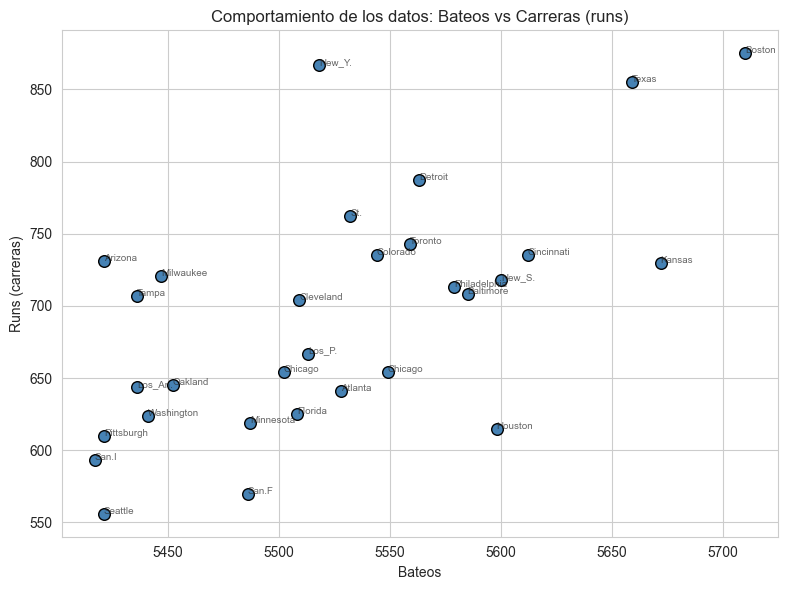

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(datos['bateos'], datos['runs'], color='steelblue', edgecolor='black', s=70)
plt.title('Comportamiento de los datos: Bateos vs Carreras (runs)')
plt.xlabel('Bateos')
plt.ylabel('Runs (carreras)')
for i, txt in enumerate(datos['equipos']):
    plt.annotate(txt, (datos['bateos'].iloc[i], datos['runs'].iloc[i]), fontsize=7, alpha=0.7)
plt.tight_layout()
plt.savefig('grafica_dispersion_beisbol.png', dpi=120)
plt.show()


**Interpretación:** Se observa una tendencia positiva: a mayor número de bateos, mayor número de carreras
anotadas por el equipo, lo cual respalda el uso de un modelo de regresión lineal.

### Paso 3. Preparación de variables y división entrenamiento/prueba

In [6]:
X = datos['bateos'].values.reshape(-1, 1)
y = datos['runs'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print('Entrenamiento:', X_train.shape, ' Prueba:', X_test.shape)


Entrenamiento: (24, 1)  Prueba: (6, 1)


### Paso 4. Entrenamiento del modelo base

In [7]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

print('Intercepto:', regressor.intercept_)
print('Coeficiente (pendiente):', regressor.coef_)


Intercepto: [-2837.77687486]
Coeficiente (pendiente): [[0.63897479]]


In [8]:
y_pred = regressor.predict(X_test)
comparacion = pd.DataFrame({'Real': y_test.flatten(), 'Predicho': y_pred.flatten()})
comparacion


,Real,Predicho
0,787,716.839887
1,593,623.549568
2,735,748.149652
3,708,730.897333
4,624,638.884963
5,707,635.690089


### Paso 5. Evaluación del modelo base (métricas)

In [9]:
print('Error Absoluto Medio (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Error Cuadrático Medio (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Raíz del Error Cuadrático Medio (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Coeficiente de Determinación R2:', metrics.r2_score(y_test, y_pred))


Error Absoluto Medio (MAE): 37.158589869587935
Error Cuadrático Medio (MSE): 1976.597374864583
Raíz del Error Cuadrático Medio (RMSE): 44.4589403254799
Coeficiente de Determinación R2: 0.5399576825420558


### Paso 6. Gráfica comparativa — valores reales contra predichos

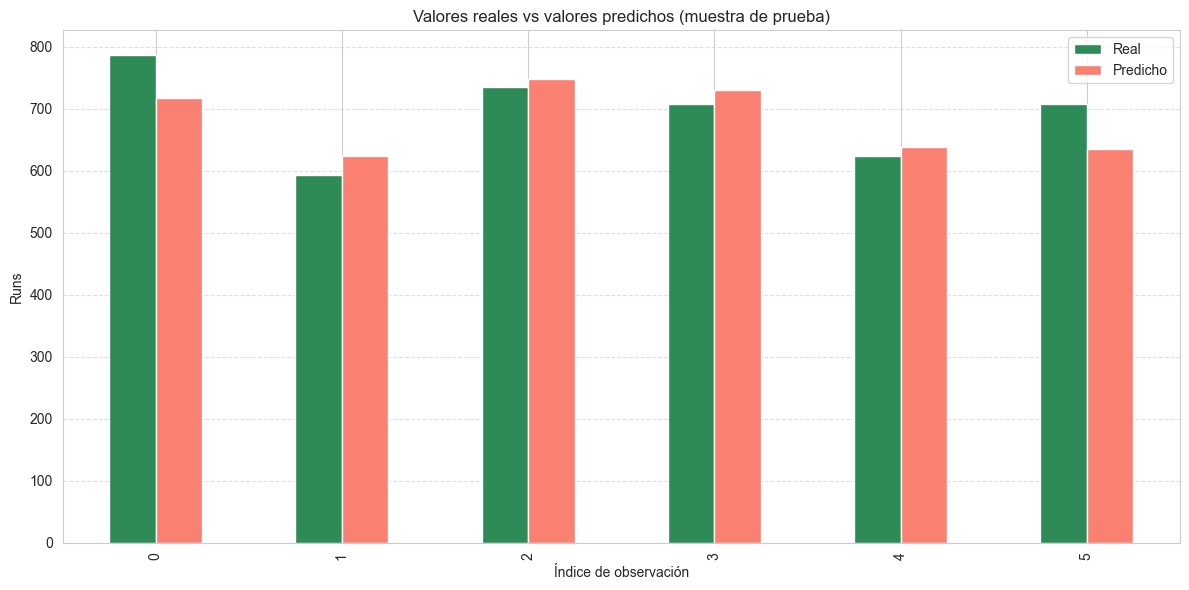

In [10]:
comparacion.head(15).plot(kind='bar', figsize=(12, 6), color=['seagreen', 'salmon'])
plt.title('Valores reales vs valores predichos (muestra de prueba)')
plt.xlabel('Índice de observación')
plt.ylabel('Runs')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('grafica_reales_vs_predichos_beisbol.png', dpi=120)
plt.show()


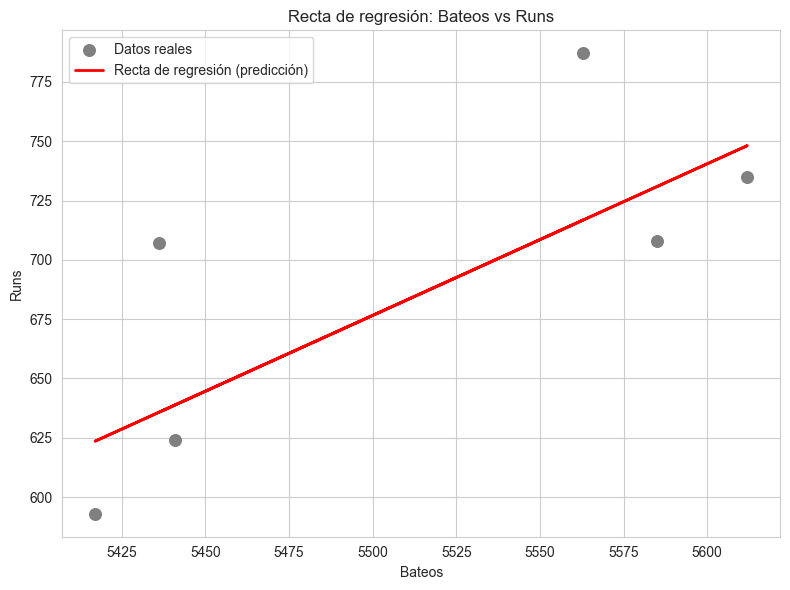

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='gray', label='Datos reales', s=70)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Recta de regresión (predicción)')
plt.title('Recta de regresión: Bateos vs Runs')
plt.xlabel('Bateos')
plt.ylabel('Runs')
plt.legend()
plt.tight_layout()
plt.savefig('grafica_recta_regresion_beisbol.png', dpi=120)
plt.show()


**Interpretación:** El modelo captura correctamente la tendencia creciente entre bateos y carreras. Los
puntos predichos (línea roja) se mantienen cercanos a los valores reales, lo que se confirma con el
coeficiente de determinación R² obtenido arriba.

### Paso 7. Optimización del modelo — búsqueda de hiperparámetros

In [12]:
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=1)

space = dict()
space['fit_intercept'] = [True, False]
space['positive'] = [True, False]
space['copy_X'] = [True, False]

search_random = RandomizedSearchCV(LinearRegression(), space, n_iter=8,
                                    scoring='neg_mean_absolute_error', n_jobs=-1, cv=cv, random_state=1)
result_random = search_random.fit(X, y)
print('RandomizedSearchCV -> Mejor puntuación:', result_random.best_score_)
print('RandomizedSearchCV -> Mejores hiperparámetros:', result_random.best_params_)


RandomizedSearchCV -> Mejor puntuación: -55.11281875558739
RandomizedSearchCV -> Mejores hiperparámetros: {'positive': True, 'fit_intercept': True, 'copy_X': True}


In [13]:
search_grid = GridSearchCV(LinearRegression(), space, scoring='neg_mean_absolute_error', n_jobs=-1, cv=cv)
result_grid = search_grid.fit(X, y)
print('GridSearchCV -> Mejor puntuación:', result_grid.best_score_)
print('GridSearchCV -> Mejores hiperparámetros:', result_grid.best_params_)


GridSearchCV -> Mejor puntuación: -55.11281875558739
GridSearchCV -> Mejores hiperparámetros: {'copy_X': True, 'fit_intercept': True, 'positive': True}


### Paso 8. Reentrenamiento con los mejores hiperparámetros y evaluación final

In [14]:
mejores_params = result_grid.best_params_
regressor_opt = LinearRegression(**mejores_params)
regressor_opt.fit(X_train, y_train)
y_pred_opt = regressor_opt.predict(X_test)

print('--- Modelo optimizado ---')
print('Intercepto:', regressor_opt.intercept_)
print('Coeficiente:', regressor_opt.coef_)
print('MAE:', metrics.mean_absolute_error(y_test, y_pred_opt))
print('MSE:', metrics.mean_squared_error(y_test, y_pred_opt))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_opt)))
print('R2:', metrics.r2_score(y_test, y_pred_opt))


--- Modelo optimizado ---
Intercepto: [-2837.77687486]
Coeficiente: [[0.63897479]]
MAE: 37.158589869587935
MSE: 1976.597374864583
RMSE: 44.4589403254799
R2: 0.5399576825420558


## Conclusión / Interpretación final
El modelo de regresión lineal simple explica adecuadamente la relación entre bateos y carreras anotadas.
La búsqueda de hiperparámetros (`RandomizedSearchCV` y `GridSearchCV`) confirmó que la configuración por
defecto (`fit_intercept=True`) es la más adecuada, ya que el modelo ya se encontraba cerca del óptimo dado
que solo existe una variable predictora. El error medio (MAE) obtenido indica el margen de error promedio,
en número de carreras, entre lo predicho y lo real.

**Enlace al repositorio con el modelo:** https://github.com/YosueCh/2a.-Evaluaci-n-Extracci-n-de-conocimiento-en-bases-de-datos.git
